# Data Analysis 6: Curve Fitting - Continued 

 
## Contents 
In this `data_analysis_6` notebook we focus on :
1. Curve Fitting using the `scipy.optimize.curve_fit` function previously introduced in the notebook [data_analysis_4.ipynb](data_analysis_4.ipynb)

The advantage of the `curve_fit` function over the numpy `Polynomial.fit` function is that `curve_fit` can be used for *any* function, and not just polynomials. 

In [6]:
# Imports ...
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.optimize import curve_fit

# 1. Synthesizing Data

In the cells below we will create some data using 
1. Functions based around exponentials
2. Trig. Functions

We will then use `curve_fit` to fit these data. 

N.B. Because we know that curve_fit is going to want us to define the functions-to-be-fit, we go ahead and do that here too (see `trig_func` and `exp_func`) 

In [8]:
def trig_func(x, A, B):
    return A*np.sin(x) + B*np.cos(x)

def create_trig_data(n_points = 4 , add_random_error = False, sigma = 0.1 , A=1, B=2):
    """
    Convenience function to create some synthetic data from some trig model(s) 

    optional arguments 
    ------------------
    n_points: int
     - number of points to be made 

    add_random_error: boolean
     - whether or not we want to add noise to the data 
     
    sigma: float
     - if we are adding noise, what standard-deviation do we want to use for the distribution of noise/uncertainty
       
    A
    B
    
    returns 
    ------------------
    x_values: 
    y_values: 
    """
        
    # Choose some x-values at which we will evaluate the function 
    x_values = np.random.default_rng().uniform(0,2*np.pi,n_points)
    
    # Evaluate the y-values at the chosen x-values
    y_values = trig_func(x_values, A, B)
    
    # If desired, add some random "errors"
    if add_random_error:
        mu=0
        y_random = np.random.default_rng().normal(mu, sigma, n_points)
        y_values = y_values + y_random
    
    return x_values, y_values

def exp_func(x, A, B, C):
    return A + B*np.exp(x) + x*C

def create_exp_data(n_points = 4 , add_random_error = False, sigma = 0.1, A=1, B=2, C=3):
    """
    Convenience function to create some synthetic data from some model(s) based around exponentials

    optional arguments 
    ------------------
    n_points: int
     - number of points to be made 

    add_random_error: boolean
     - whether or not we want to add noise to the data 
     
    sigma: float
     - if we are adding noise, what standard-deviation do we want to use for the distribution of noise/uncertainty
       
    A
    B
    C
    
    returns 
    ------------------
    x_values: 
    y_values: 
    """
    # Define the coefficients 
    A, B, C = 1, 2, 3
        
    # Choose some x-values at which we will evaluate the function 
    x_values = np.random.default_rng().uniform(0,5,n_points)
    
    # Evaluate the y-values at the chosen x-values
    y_values = exp_func(x_values, A, B, C)
    
    # If desired, add some random "errors"
    if add_random_error:
        mu=0
        y_random = np.random.default_rng().normal(mu, sigma, n_points)
        y_values = y_values + y_random
    
    return x_values, y_values

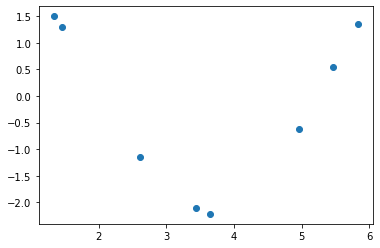

In [9]:
# Generate & plot the *TRIG* data
x_trig, y_trig = create_trig_data(n_points = 8 , add_random_error = True, sigma = 0.1 )
plt.scatter(x_trig, y_trig)

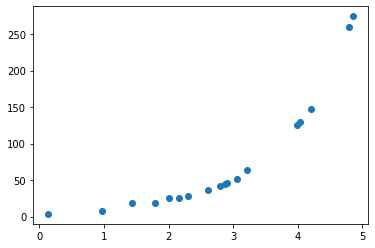

In [10]:
# Generate & plot the *exponential-based- data
x_exp, y_exp = create_exp_data(n_points = 18 , add_random_error = True, sigma = 2.0 )
plt.scatter(x_exp, y_exp)

# 3.2 Fitting the Trig-Data

In [11]:
# Fit for the parameters function we defined above:
popt, pcov = curve_fit(trig_func, x_trig, y_trig)
popt  

array([1.06973667, 1.94619184])

# 3.3 Fitting the Data from the Exponential-Related Function

In [12]:
# Fit for the parameters function we defined above:
popt, pcov = curve_fit(exp_func, x_trig, y_trig)
popt 

array([ 3.34192878,  0.02454893, -1.67140816])

# Exercise (A)
1. Define a function (named `exercise_func`) that evaluates $A + B*e^x + C*cos(x)$
 - Ensure that the arguments for `exercise_func` are ... `exercise_func(x_values, A, B, C)`
2. Use the function named `create_exercise_data` that is supplied below. It will call `exercise_func`.
3. Use `create_exercise_data` to generate 10 randomly selected data points in arrays `x_exercise` and `y_exercise`
 - Try this using `add_random_error = False`
4. Use `curve_fit` to fit a function of the form `exercise_func` to the data in arrays `x_exercise` and `y_exercise`
5. Plot the data & the fitted function 
6. Repeat steps 3. - 6. using `add_random_error = True`

In [7]:
def create_exercise_data(n_points = 4 , add_random_error = False, sigma = 1.0, A=1, B=2, C=3):
    """
    Convenience function to create some synthetic data from model defined in exercise 
    
    Requires that there exist a function named "exercise_func" with arguments (x_values, A, B, C)

    optional arguments 
    ------------------
    n_points: int
     - number of points to be made 

    add_random_error: boolean
     - whether or not we want to add noise to the data 
     
    sigma: float
     - if we are adding noise, what standard-deviation do we want to use for the distribution of noise/uncertainty

    A : float 
     - Coefficient required by the function 'exercise_func'
    B : float 
     - Coefficient required by the function 'exercise_func'
    C : float 
     - Coefficient required by the function 'exercise_func'
    
    returns 
    ------------------
    x_values: 
    y_values: 
    """
        
    # Choose some x-values at which we will evaluate the function 
    x_values = np.random.default_rng().uniform(0,2*np.pi,n_points)
    
    # Evaluate the y-values at the chosen x-values
    y_values = exercise_func(x_values, A, B, C)
    
    # If desired, add some random "errors"
    if add_random_error:
        mu=0
        y_random = np.random.default_rng().normal(mu, sigma, n_points)
        y_values = y_values + y_random
    
    return x_values, y_values
